In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=5, suppress=True)

In [3]:
from dataclasses import dataclass

import numpy as np

from dynprolib.pyfriendly import PortfolioConfig
from dynprolib.pyfriendly.portfolio_core import (
    apply_inverse_basis_chain,
    build_model_arrays,
    cartesian_grid,
    gauss_hermite_multinormal,
    linear_spline_basis,
    model_inverse_utility,
    model_utility,
    tensor_basis_interpolate,
    uniform_nodes,
)


@dataclass
class MutualFundConfig(PortfolioConfig):
    theta: float = 1.0
    gamma0: float = 0.057757
    EgRM: float = 1.073826
    n: tuple[int, int, int, int] = (7, 7, 5, 21)
    q: int = 21 #41
    q2: int = 5 #25
    m: tuple[int, int, int] = (3, 3, 3)
    var_cov: tuple[tuple[float, float, float], tuple[float, float, float], tuple[float, float, float]] = (
        (0.030186, 0.0, 0.0),
        (0.0, 0.017292, 0.0),
        (0.0, 0.0, 0.026941),
    )



def mutual_bounds_x(state, cfg):
    state = np.asarray(state, dtype=float)
    x_lower = np.full(state.shape[0], cfg.sminv[2], dtype=float) - state[:, 2]
    x_upper_land = np.full(state.shape[0], cfg.smaxv[2], dtype=float) - state[:, 2]
    sell_price = (1.0 - cfg.tcs) * state[:, 1] + (1.0 - cfg.fds) * cfg.fme
    buy_price = (1.0 + cfg.tcb) * state[:, 1] + cfg.fme
    x_upper_debt = np.maximum(
        0.0,
        (state[:, 3] - (1.0 - cfg.dau) * sell_price * state[:, 2]) / (buy_price - cfg.dau * sell_price),
    )
    return x_lower, np.minimum(x_upper_land, x_upper_debt)



def mutual_bounds_xm(state, trade_x, cfg):
    state = np.asarray(state, dtype=float)
    trade_x = np.asarray(trade_x, dtype=float)
    if np.isscalar(trade_x):
        trade_x = np.full(state.shape[0], float(trade_x), dtype=float)
    if np.all(state[:, 2] + trade_x < 1.0):
        xml = state[:, 3].copy()
        xmu = state[:, 3].copy()
        return xml, xmu

    s2bs = (1.0 + cfg.tcb) * state[:, 1] + cfg.fme
    sell_mask = trade_x < 0
    s2bs[sell_mask] = (1.0 - cfg.tcs) * state[sell_mask, 1] + (1.0 - cfg.fds) * cfg.fme
    s2v = (1.0 - cfg.tcs) * state[:, 1] + (1.0 - cfg.fds) * cfg.fme
    at = state[:, 3] - s2v * state[:, 2]
    xml = np.zeros(state.shape[0], dtype=float)
    xmu = np.maximum(0.0, at - s2bs * trade_x + cfg.dau * s2v * (state[:, 2] + trade_x))
    return xml, xmu



def mutual_transition_next_state(state, trade_x, mutual_x, shocks, cfg, sminv, smaxv):
    state = np.asarray(state, dtype=float)
    trade_x = np.asarray(trade_x, dtype=float)
    mutual_x = np.asarray(mutual_x, dtype=float)
    shocks = np.asarray(shocks, dtype=float)
    next_state = np.zeros_like(state, dtype=float)

    growth_r = np.exp(cfg.beta0 + cfg.beta1 * np.log(state[:, 0]) + shocks[:, 0])
    growth_p = np.exp(cfg.alpha0 + cfg.alpha1 * np.log(state[:, 1]) + cfg.alpha2 * np.log(state[:, 0]) + shocks[:, 1])
    growth_m = np.exp(cfg.gamma0 + shocks[:, 2])

    next_state[:, 0] = np.clip(growth_r, sminv[0], smaxv[0])
    next_state[:, 1] = np.clip(growth_p, sminv[1], smaxv[1])
    next_state[:, 2] = state[:, 2] + trade_x

    sell_price_now = (1.0 - cfg.tcs) * state[:, 1] + (1.0 - cfg.fds) * cfg.fme
    sell_price_next = (1.0 - cfg.tcs) * next_state[:, 1] + (1.0 - cfg.fds) * cfg.fme
    buy_price = (1.0 + cfg.tcb) * state[:, 1] + cfg.fme
    sell_mask = trade_x < 0
    buy_price[sell_mask] = (1.0 - cfg.tcs) * state[sell_mask, 1] + (1.0 - cfg.fds) * cfg.fme

    equity_now = state[:, 3] - sell_price_now * state[:, 2]
    low_land = next_state[:, 2] < 1.0

    # MATLAB gstate.m uses vector if-logic, equivalent to all(low_land) in NumPy.
    if np.all(low_land):
        next_state[:, 3] = cfg.EgRM * state[:, 3]
        return next_state

    cash_after_cost = equity_now - buy_price * trade_x - cfg.cost * next_state[:, 2] - mutual_x
    rate_high_land = np.full(state.shape[0], cfg.rp, dtype=float)
    rate_high_land[cash_after_cost < 0] = cfg.rn
    wealth_high_land = (1.0 + rate_high_land) * cash_after_cost + next_state[:, 0] * next_state[:, 2] + sell_price_next * next_state[:, 2] + growth_m * mutual_x

    next_state[:, 3] = wealth_high_land
    return next_state



def mutual_value_function(state, coeffs, t, controls, cfg, arrays, shock_nodes, shock_weights):
    state = np.asarray(state, dtype=float)
    controls = np.asarray(controls, dtype=float)
    trade_x = controls[:, 0]
    mutual_x = controls[:, 1]
    value = np.zeros(state.shape[0], dtype=float)

    for k in range(shock_nodes.shape[0]):
        shocks = np.tile(shock_nodes[k], (state.shape[0], 1))
        next_state = mutual_transition_next_state(state, trade_x, mutual_x, shocks, cfg, arrays['sminv'], arrays['smaxv'])
        v_k = np.zeros(state.shape[0], dtype=float)
        low_land = next_state[:, 2] < 1.0

        # MATLAB valuefw.m uses vector if-logic, equivalent to all(low_land) in NumPy.
        if np.all(low_land):
            if cfg.theta == 0:
                v_k[:] = (cfg.EgRM ** (cfg.T - t + 1)) * state[:, 3]
            else:
                v_k[:] = np.log(np.maximum(state[:, 3], 1e-12)) + cfg.gamma0 * (cfg.T - t + 1)
        else:
            gf4 = next_state[:, 3]
            if coeffs is None or coeffs.size == 0:
                v_k[:] = model_utility(gf4, cfg.b, cfg.theta)
            else:
                nbri = np.where(gf4 > 0)[0]
                if nbri.size > 0:
                    gm4 = np.minimum(next_state[nbri, 3], arrays['smaxv'][3])
                    gd = next_state[nbri, 3] - gm4
                    g_eval = next_state[nbri].copy()
                    g_eval[:, 3] = gm4
                    phi = [
                        linear_spline_basis(int(arrays['n'][d]), float(arrays['smin'][d]), float(arrays['smax'][d]), g_eval[:, d])
                        for d in range(len(arrays['n']))
                    ]
                    v_interp = tensor_basis_interpolate(phi, coeffs.reshape(-1, 1)).reshape(-1)
                    if cfg.theta == 0:
                        tw = v_interp
                    else:
                        logb = np.log(cfg.b)
                        tw = np.where(v_interp >= logb, np.exp(np.minimum(v_interp, 700.0)), (v_interp * cfg.b) / logb)
                    v_nbri = v_interp.copy()
                    over_cap = next_state[nbri, 3] > arrays['smaxv'][3]
                    if np.any(over_cap):
                        v_nbri[over_cap] = model_utility(
                            tw[over_cap] + ((1.0 + cfg.rp) ** (cfg.T - t)) * gd[over_cap],
                            cfg.b,
                            cfg.theta,
                        )
                    v_k[nbri] = v_nbri
                neg = np.where(gf4 <= 0)[0]
                if neg.size > 0:
                    v_k[neg] = model_utility(((1.0 + cfg.rn) ** (cfg.T - t)) * gf4[neg], cfg.b, cfg.theta)

        value += v_k * shock_weights[k]
    return value



def mutual_vmaxhm(state, coeffs, t, xqi, cfg, arrays, shock_nodes, shock_weights):
    xml, xmu = mutual_bounds_xm(state, xqi, cfg)
    nn = state.shape[0]
    xmq = np.zeros((cfg.q2, nn), dtype=float)
    vxq2 = np.zeros((cfg.q2, nn), dtype=float)
    gap = (xmu - xml) / (cfg.q2 - 1)

    for qj in range(cfg.q2):
        xmqj = xml + gap * qj
        controls = np.column_stack([np.asarray(xqi, dtype=float), xmqj])
        vxq2[qj, :] = mutual_value_function(state, coeffs, t, controls, cfg, arrays, shock_nodes, shock_weights)
        xmq[qj, :] = xmqj

    ind = np.argmax(vxq2, axis=0)
    j = np.arange(nn)
    xmqi = xmq[ind, j]
    vqi = vxq2[ind, j]
    return xmqi, vqi



def mutual_vmaxh(state, coeffs, t, cfg, arrays, shock_nodes, shock_weights):
    xl, xu = mutual_bounds_x(state, cfg)
    nn = state.shape[0]
    vxq = np.zeros((cfg.q + 2, nn), dtype=float)
    xq = np.zeros((cfg.q + 2, nn), dtype=float)
    xmq = np.zeros((cfg.q + 2, nn), dtype=float)
    gap = (xu - xl) / (cfg.q - 1)

    for qi in range(cfg.q + 2):
        if qi == 0:
            xqi = np.zeros(nn, dtype=float)
        elif qi == 1:
            xqi = -state[:, 2]
        else:
            xqi = xl + gap * (qi - 2)
        xmqi, vqi = mutual_vmaxhm(state, coeffs, t, xqi, cfg, arrays, shock_nodes, shock_weights)
        xq[qi, :] = xqi
        xmq[qi, :] = xmqi
        vxq[qi, :] = vqi

    ind = np.argmax(vxq, axis=0)
    j = np.arange(nn)
    x = xq[ind, j]
    xm = xmq[ind, j]
    v = vxq[ind, j]
    return x, xm, v



def solve_mutual_coefficients(cfg):
    arrays = build_model_arrays(cfg)
    n = arrays['n']
    shock_nodes, shock_weights = gauss_hermite_multinormal(arrays['m'], arrays['Ee'], arrays['VarCov'])
    state_nodes = [uniform_nodes(int(n[d]), float(arrays['smin'][d]), float(arrays['smax'][d])) for d in range(len(n))]
    inverse_basis = [
        np.linalg.inv(linear_spline_basis(int(n[d]), float(arrays['smin'][d]), float(arrays['smax'][d]), state_nodes[d]))
        for d in range(len(n))
    ]
    state_grid = cartesian_grid(state_nodes)

    n_points = state_grid.shape[0]
    coeffs_over_time = np.zeros((n_points, cfg.T), dtype=float)
    active_idx = np.where(state_grid[:, 3] > 1.0)[0]
    active_states = state_grid[active_idx]
    coeffs = None

    for t in range(cfg.T, cfg.t1 - 1, -1):
        _, _, value = mutual_vmaxh(active_states, coeffs, t, cfg, arrays, shock_nodes, shock_weights)
        value_full = np.full(n_points, model_utility(0.0, cfg.b, cfg.theta), dtype=float)
        value_full[active_idx] = value
        coeffs = apply_inverse_basis_chain(inverse_basis, value_full.reshape(-1, 1)).reshape(-1)
        coeffs_over_time[:, t - 1] = coeffs

    return coeffs_over_time



def mutual_policy_grid(copt, cfg, t=0, Lt=600.0, Rt=365.0, wealth_levels=None):
    arrays = build_model_arrays(cfg)
    shock_nodes, shock_weights = gauss_hermite_multinormal(arrays['m'], arrays['Ee'], arrays['VarCov'])
    p_vals = np.arange(cfg.sminv[1], cfg.smaxv[1] + 5.0, 5.0, dtype=float)
    if wealth_levels is None:
        w_vals = np.arange(400_000.0, 600_000.0, 1_000_000.0, dtype=float)
    else:
        w_vals = np.asarray(wealth_levels, dtype=float)

    coeffs = None if t == cfg.T else copt[:, t]
    x_policy = np.zeros((p_vals.size, w_vals.size), dtype=float)
    xm_policy = np.zeros((p_vals.size, w_vals.size), dtype=float)

    for wi, wealth_t in enumerate(w_vals):
        state = np.zeros((p_vals.size, len(arrays['n'])), dtype=float)
        state[:, 0] = Rt
        state[:, 1] = p_vals
        state[:, 2] = Lt
        state[:, 3] = wealth_t
        x_opt, xm_opt, _ = mutual_vmaxh(state, coeffs, t, cfg, arrays, shock_nodes, shock_weights)
        x_policy[:, wi] = x_opt
        xm_policy[:, wi] = xm_opt

    return {"P": p_vals, "W": w_vals, "X": x_policy, "XM": xm_policy, "arrays": arrays}


class MutualFundModel:
    def __init__(self, config=None):
        self.config = config or MutualFundConfig()

    def transition(self, R, P, L, W, x, xm, eps1, eps2, eps3):
        state = np.array([[R, P, L, W]], dtype=float)
        shocks = np.array([[eps1, eps2, eps3]], dtype=float)
        next_state = mutual_transition_next_state(
            state=state,
            trade_x=np.array([x], dtype=float),
            mutual_x=np.array([xm], dtype=float),
            shocks=shocks,
            cfg=self.config,
            sminv=np.array(self.config.sminv, dtype=float),
            smaxv=np.array(self.config.smaxv, dtype=float),
        )
        return tuple(next_state[0])

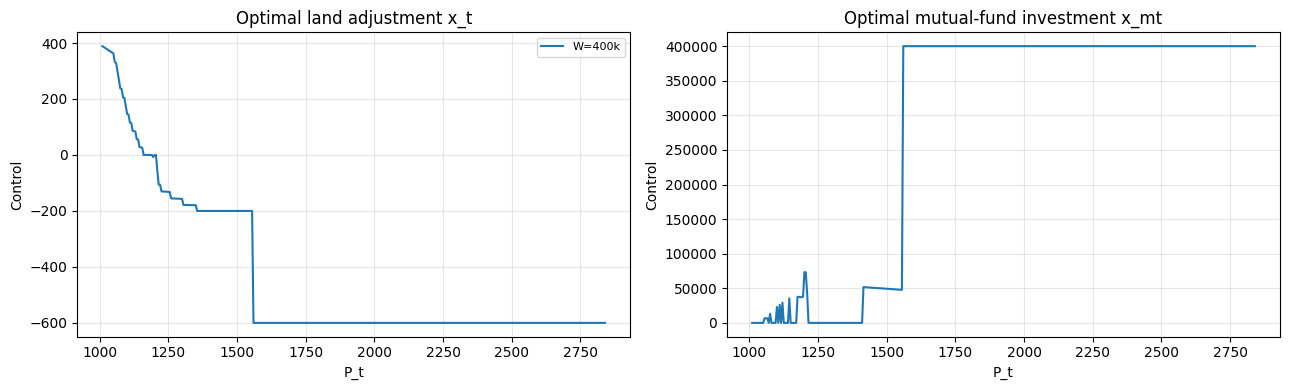

In [4]:

# Build a mutual-fund policy slice and visualize x_t and x_mt against P_t.
model=MutualFundModel()
model.config.Ee = (0.0, 0.0, 0.0)
model.config.var_cov = (
    (0.030186, 0.0, 0.0),
    (0.0, 0.017292, 0.0),
    (0.0, 0.0, 0.026941),
)
copt = solve_mutual_coefficients(model.config)
policy = mutual_policy_grid(copt, model.config, t=model.config.T - 1, Lt=600.0, Rt=365.0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
wealth_labels = [f'W={int(w/1000)}k' for w in policy['W']]

for wi, label in enumerate(wealth_labels):
    axes[0].plot(policy['P'], policy['X'][:, wi], label=label)
    axes[1].plot(policy['P'], policy['XM'][:, wi], label=label)

axes[0].set_title('Optimal land adjustment x_t')
axes[1].set_title('Optimal mutual-fund investment x_mt')
for ax in axes:
    ax.set_xlabel('P_t')
    ax.set_ylabel('Control')
    ax.grid(True, alpha=0.3)
axes[0].legend(loc='best', fontsize=8)
fig.tight_layout()
plt.show()

In [5]:
policy['P']


array([1010., 1015., 1020., 1025., 1030., 1035., 1040., 1045., 1050.,
       1055., 1060., 1065., 1070., 1075., 1080., 1085., 1090., 1095.,
       1100., 1105., 1110., 1115., 1120., 1125., 1130., 1135., 1140.,
       1145., 1150., 1155., 1160., 1165., 1170., 1175., 1180., 1185.,
       1190., 1195., 1200., 1205., 1210., 1215., 1220., 1225., 1230.,
       1235., 1240., 1245., 1250., 1255., 1260., 1265., 1270., 1275.,
       1280., 1285., 1290., 1295., 1300., 1305., 1310., 1315., 1320.,
       1325., 1330., 1335., 1340., 1345., 1350., 1355., 1360., 1365.,
       1370., 1375., 1380., 1385., 1390., 1395., 1400., 1405., 1410.,
       1415., 1420., 1425., 1430., 1435., 1440., 1445., 1450., 1455.,
       1460., 1465., 1470., 1475., 1480., 1485., 1490., 1495., 1500.,
       1505., 1510., 1515., 1520., 1525., 1530., 1535., 1540., 1545.,
       1550., 1555., 1560., 1565., 1570., 1575., 1580., 1585., 1590.,
       1595., 1600., 1605., 1610., 1615., 1620., 1625., 1630., 1635.,
       1640., 1645.,

In [6]:
import pandas as pd

# Table-8 replication for the model with mutual funds.
# Paper setup uses: initial wealth $1,000,000, x-grid q=41, mutual-fund grid q2=25.
rng = np.random.default_rng(42)
n_sims = 500
n_years = 10

model=MutualFundModel()
cfg = model.config
cfg.Ee = (0.0, 0.0, 0.0)
cfg.q = 41
cfg.q2 = 25
cfg.theta = 1.0
cfg.m = (3, 3, 3)
cfg.var_cov = (
    (0.030186, 0.0, 0.0),
    (0.0, 0.017292, 0.0),
    (0.0, 0.0, 0.026941),
)

# Reuse copt when possible; this is the main runtime bottleneck.
cfg_key = (cfg.n, cfg.q, cfg.q2, cfg.m, cfg.T, cfg.t1, cfg.Ee, cfg.var_cov)
if "_mutual_copt_cache" not in globals():
    _mutual_copt_cache = {}
if cfg_key not in _mutual_copt_cache:
    print(f"Solving coefficients with q={cfg.q}, q2={cfg.q2}...")
    _mutual_copt_cache[cfg_key] = solve_mutual_coefficients(cfg)
    print("Done solving.")
else:
    print(f"Using cached coefficients (q={cfg.q}, q2={cfg.q2})")
copt = _mutual_copt_cache[cfg_key]

arrays = build_model_arrays(cfg)
shock_nodes, shock_weights = gauss_hermite_multinormal(arrays["m"], arrays["Ee"], arrays["VarCov"])
mean_e = np.asarray(cfg.Ee, dtype=float)
cov_e = np.asarray(cfg.var_cov, dtype=float)

# Table-8 initial state from paper.
initial_wealth = 1_000_000.0
states = np.zeros((n_sims, 4), dtype=float)
states[:, 0] = 365.0        # R_0
states[:, 1] = 1775.0       # P_0
states[:, 2] = 600.0        # L_0
states[:, 3] = initial_wealth

summary_rows = [
    {
        "Year": 0,
        "Expected net wealth ($)": states[:, 3].mean(),
        "St. dev. of net wealth ($)": np.nan,
        "Expected farmland (acres)": states[:, 2].mean(),
        "Prob. of exiting farming": 0.0,
    }
]

for year in range(1, n_years + 1):
    # MATLAB pathT.m: yr=0..years-1, c1=copt(:,yr+1), and t passed to vmaxh is yr.
    yr_idx = year - 1
    coeffs_t = copt[:, yr_idx]
    t_eval = yr_idx

    # Follow MATLAB "ini" set: active farming states are L >= sminv(3)-1 and W > 0.
    active_mask = (states[:, 2] >= (arrays["sminv"][2] - 1.0)) & (states[:, 3] > 0.0)
    active_idx = np.where(active_mask)[0]

    next_states = states.copy()

    if active_idx.size > 0:
        active_states = states[active_idx]
        x_opt, xm_opt, _ = mutual_vmaxh(
            active_states, coeffs_t, t_eval, cfg, arrays, shock_nodes, shock_weights
        )

        shocks = rng.multivariate_normal(mean=mean_e, cov=cov_e, size=active_idx.size)
        next_active = mutual_transition_next_state(
            active_states, x_opt, xm_opt, shocks, cfg, arrays["sminv"], arrays["smaxv"]
        )
        next_states[active_idx] = next_active

    # Follow MATLAB "outi" transition: all non-active states are absorbing out-of-farming states.
    out_idx = np.where(~active_mask)[0]
    if out_idx.size > 0:
        next_states[out_idx, 2] = 0.0
        positive_wealth = next_states[out_idx, 3] >= 0.0
        next_states[out_idx[positive_wealth], 3] = cfg.EgRM * next_states[out_idx[positive_wealth], 3]
        next_states[out_idx[~positive_wealth], 3] = (1.0 + cfg.rn) * next_states[out_idx[~positive_wealth], 3]

    states = next_states
    exited = (states[:, 2] < 1.0) | (states[:, 3] <= 0.0)

    summary_rows.append(
        {
            "Year": year,
            "Expected net wealth ($)": states[:, 3].mean(),
            "St. dev. of net wealth ($)": states[:, 3].std(ddof=1),
            "Expected farmland (acres)": states[:, 2].mean(),
            "Prob. of exiting farming": exited.mean(),
        }
    )

mutual_estimates_df = pd.DataFrame(summary_rows)
table_display = mutual_estimates_df.copy()
table_display["Expected net wealth ($)"] = table_display["Expected net wealth ($)"].map(lambda v: f"{v:,.0f}")
table_display["St. dev. of net wealth ($)"] = table_display["St. dev. of net wealth ($)"].map(
    lambda v: "-" if pd.isna(v) else f"{v:,.0f}"
)
table_display["Expected farmland (acres)"] = table_display["Expected farmland (acres)"].map(lambda v: f"{v:,.0f}")
table_display["Prob. of exiting farming"] = table_display["Prob. of exiting farming"].map(lambda v: f"{v:.3f}")

table_display

Solving coefficients with q=41, q2=25...
Done solving.


,Year,Expected net wealth ($),St. dev. of net wealth ($),Expected farmland (acres),Prob. of exiting farming
0,0,"1,000,000",-,600,0.000
1,1,"1,068,448","152,910",600,0.000
2,2,"1,147,462","237,084",615,0.006
3,3,"1,235,916","301,025",686,0.018
4,4,"1,354,284","404,999",744,0.044
5,5,"1,488,200","517,152",800,0.062
6,6,"1,618,191","613,691",846,0.076
7,7,"1,738,465","710,478",875,0.104
8,8,"1,902,107","808,122",886,0.132
9,9,"2,074,814","948,021",906,0.164


In [10]:
import numpy as np
import pandas as pd

# Table 7-style policy table for the model WITH mutual funds.
# Uses the same (P, W) states as Finished_model and reports optimal controls from the mutual solver.

cfg_table7_mutual = MutualFundConfig()
cfg_table7_mutual.theta = 1.0
cfg_table7_mutual.n = (7, 7, 5, 21)
cfg_table7_mutual.q = 41
cfg_table7_mutual.q2 = 25
cfg_table7_mutual.m = (3, 3, 3)
cfg_table7_mutual.T = 19
cfg_table7_mutual.t1 = 1
cfg_table7_mutual.Ee = (0.0, 0.0, 0.0)
cfg_table7_mutual.var_cov = (
    (0.030186, 0.0, 0.0),
    (0.0, 0.017292, 0.0),
    (0.0, 0.0, 0.026941),
)

cache_key = (
    cfg_table7_mutual.n,
    cfg_table7_mutual.q,
    cfg_table7_mutual.q2,
    cfg_table7_mutual.m,
    cfg_table7_mutual.T,
    cfg_table7_mutual.t1,
    cfg_table7_mutual.theta,
    cfg_table7_mutual.Ee,
    cfg_table7_mutual.var_cov,
)
if "_mutual_copt_cache" not in globals():
    _mutual_copt_cache = {}
if cache_key not in _mutual_copt_cache:
    print("Solving mutual-fund coefficients for Table 7-style policy table...")
    _mutual_copt_cache[cache_key] = solve_mutual_coefficients(cfg_table7_mutual)
    print("Done solving.")
else:
    print("Using cached mutual-fund coefficients for Table 7-style policy table.")

copt_table7_mutual = _mutual_copt_cache[cache_key]
arrays_m = build_model_arrays(cfg_table7_mutual)
shock_nodes_m, shock_weights_m = gauss_hermite_multinormal(arrays_m["m"], arrays_m["Ee"], arrays_m["VarCov"])

def debt_to_farm_asset_ratio(P, L, W, tcs=0.06, fds=0.07, fme=300.0):
    pps = (1.0 - tcs) * P + (1.0 - fds) * fme
    lafa = (W / (pps * L)) - 1.0
    return max(0.0, -lafa)

def resulting_dfa_after_trade(P, L, W, x, xm=0.0, tcs=0.06, tcb=0.01, fds=0.07, fme=300.0):
    """Compute resulting DFA after farmland trade and mutual-fund investment."""
    pps = (1.0 - tcs) * P + (1.0 - fds) * fme
    ppps = (1.0 + tcb) * P + fme
    if x < 0:
        ppps = pps
    L_post = L + x
    if L_post <= 0.0:
        return 0.0
    # Account for mutual-fund investment reducing effective wealth
    lafa12f = (W - xm - pps * L - ppps * x) / (pps * L_post)
    return max(0.0, -lafa12f)

Lt = 600.0
Rt = 365.0
prices = [1500.0, 1775.0]
wealth_levels = [400_000.0, 600_000.0, 1_000_000.0]
rows = []
for P in prices:
    for W in wealth_levels:
        state = np.array([[Rt, P, Lt, W]], dtype=float)
        x_opt, xm_opt, _ = mutual_vmaxh(
            state,
            copt_table7_mutual[:, 0],
            0,
            cfg_table7_mutual,
            arrays_m,
            shock_nodes_m,
            shock_weights_m,
        )
        x_star = float(x_opt[0])
        xm_star = float(xm_opt[0])
        rows.append(
            {
                "Current farmland price ($)": int(P),
                "Net wealth ($)": int(W),
                "Debt-to-farm-asset ratio": debt_to_farm_asset_ratio(P, Lt, W),
                "Optimal farmland transaction (acres)": x_star,
                "Optimal mutual-fund investment ($)": xm_star,
                "Resulting debt-to-farm-asset ratio": resulting_dfa_after_trade(P, Lt, W, x_star, xm_star),
            }
        )

table7_with_mutual = pd.DataFrame(rows)
display_table7_with_mutual = table7_with_mutual.copy()
display_table7_with_mutual["Net wealth ($)"] = display_table7_with_mutual["Net wealth ($)"].map(lambda v: f"{v:,.0f}")
display_table7_with_mutual["Debt-to-farm-asset ratio"] = display_table7_with_mutual["Debt-to-farm-asset ratio"].map(lambda v: f"{v:.2f}")
display_table7_with_mutual["Optimal farmland transaction (acres)"] = display_table7_with_mutual["Optimal farmland transaction (acres)"].map(lambda v: f"{v:,.0f}")
display_table7_with_mutual["Optimal mutual-fund investment ($)"] = display_table7_with_mutual["Optimal mutual-fund investment ($)"].map(lambda v: f"{v:,.0f}")
display_table7_with_mutual["Resulting debt-to-farm-asset ratio"] = display_table7_with_mutual["Resulting debt-to-farm-asset ratio"].map(lambda v: f"{v:.2f}")

print("Table 7-style policy table - Model with mutual fund (simulation-based policy evaluation, theta=1)")
display(display_table7_with_mutual)


Using cached mutual-fund coefficients for Table 7-style policy table.

=== Diagnostic: Mutual-fund vs Non-mutual for high-wealth cases ===

P=1500, W=1,000,000:
  x_star=0, xm_star=347,990
  DFA before=0.01, DFA after=0.36
  pps=1689.00, ppps=1815.00
  L_post=600, liquid_after=-361,390
  pps*L_post=1,013,400

P=1775, W=1,000,000:
  x_star=0, xm_star=405,906
  DFA before=0.14, DFA after=0.49
  pps=1947.50, ppps=2092.75
  L_post=600, liquid_after=-574,406
  pps*L_post=1,168,500

Table 7-style policy table - Model with mutual fund (simulation-based policy evaluation, theta=1)


Using cached mutual-fund coefficients for Table 7-style policy table.

=== Diagnostic: Mutual-fund vs Non-mutual for high-wealth cases ===

P=1500, W=1,000,000:
  x_star=0, xm_star=347,990
  DFA before=0.01, DFA after=0.36
  pps=1689.00, ppps=1815.00
  L_post=600, liquid_after=-361,390
  pps*L_post=1,013,400

P=1775, W=1,000,000:
  x_star=0, xm_star=405,906
  DFA before=0.14, DFA after=0.49
  pps=1947.50, ppps=2092.75
  L_post=600, liquid_after=-574,406
  pps*L_post=1,168,500

Table 7-style policy table - Model with mutual fund (simulation-based policy evaluation, theta=1)


,Current farmland price ($),Net wealth ($),Debt-to-farm-asset ratio,Optimal farmland transaction (acres),Optimal mutual-fund investment ($),Resulting debt-to-farm-asset ratio
0,1500,"400,000",0.61,-200,"49,330",0.48
1,1500,"600,000",0.41,0,"209,652",0.61
2,1500,"1,000,000",0.01,0,"347,990",0.36
3,1775,"400,000",0.66,-600,"400,000",0.00
4,1775,"600,000",0.49,-200,"137,362",0.41
5,1775,"1,000,000",0.14,0,"405,906",0.49


In [11]:
# Use the already formatted table and makecell-ready headers, then save to LaTeX.
table7_makecell = display_table7_with_mutual.rename(columns=metric_makecell)

latex_str = table7_makecell.to_latex(
    index=False,
    escape=False,  # keep \makecell commands
    column_format="cccccc",
    caption="Table 7-style policy table (model with mutual fund)",
    label="tab:table7_mutual_makecell",
)

tex_path = "table7_makecell.tex"
with open(tex_path, "w") as f:
    f.write(latex_str)

print(f"Saved LaTeX table to: {tex_path}")
print("Add \\usepackage{makecell} to your LaTeX preamble.")

Saved LaTeX table to: table7_makecell.tex
Add \usepackage{makecell} to your LaTeX preamble.
